# AFD-CNN Scan on SisFall Forward Fall Samples — Fall-Peak Random-Balanced Model

This notebook applies the model trained in `SisFall_train_fall_peak_random_balanced.ipynb` to raw SisFall forward-fall recordings.

Default target data:

- `F01`: Fall forward — slip

The scan mirrors the Actigraph inference notebooks:

1. Load SisFall raw 200 Hz files.
2. Downsample ADXL345 accelerometer samples to 100 Hz, matching model training.
3. Slide a 2 s window (`200` samples) every 0.25 s (`25` samples).
4. Convert each window to the same repeat-acc `1200`-value image input used during training.
5. Restore `model/sisfall_fall_peak_random_balanced_model.ckpt`.
6. Plot prediction shading, `P(Fall)`, and raw Fall logits over time for selected recordings.


## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC = '/home/ubuntu/git/FD-CNN/src'
if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)

import importlib
import cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)


I0000 00:00:1776800436.740870   97747 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 1. Configuration

In [2]:
SISFALL_PATH = Path('/home/ubuntu/git/FD-CNN/SisFall_dataset')
FD_CNN_MODEL = '/home/ubuntu/git/FD-CNN/model/sisfall_fall_peak_random_balanced_model.ckpt'

# F01 is the SisFall forward-slip fall. Add F04/F05/etc. here if you want broader forward-fall variants.
FORWARD_FALL_CODES = ['F01']
ACTIVITY_DESC = {
    'F01': 'Fall forward - slip',
    'F04': 'Fall forward - trip',
    'F05': 'Fall forward jogging - trip',
    'F07': 'Fall forward + table brace - faint',
    'F08': 'Fall forward while getting up',
    'F10': 'Fall forward while sitting down',
    'F13': 'Fall forward while seated - faint',
}

FD_CLASS_LIST = [0, 2, 3, 4, 5, 6, 7, 9]
FD_CLASS_NAMES = {
    0: 'Fall',
    2: 'Walk',
    3: 'Jog',
    4: 'Jump',
    5: 'Up-stairs',
    6: 'Down-stairs',
    7: 'Stand→Sit',
    9: 'Sit→Stand',
}
FD_COLORS = {
    0: '#e84040',
    2: '#4a8fd4',
    3: '#56b56e',
    4: '#e09c30',
    5: '#9b6bd4',
    6: '#d47bb5',
    7: '#888888',
    9: '#aaaaaa',
}

FS_RAW = 200
FD_FS_TRAIN = 100
FD_WIN_LEN = 200     # 2 s at 100 Hz
FD_STEP = 25         # 0.25 s at 100 Hz
MAX_RECORDINGS_TO_PLOT = 12

print('Dataset root:', SISFALL_PATH)
print('Model:', FD_CNN_MODEL)
print('Forward fall codes:', FORWARD_FALL_CODES)
print(f'Sliding window: {FD_WIN_LEN / FD_FS_TRAIN:.2f} s, step {FD_STEP / FD_FS_TRAIN:.2f} s')


Dataset root: /home/ubuntu/git/FD-CNN/SisFall_dataset
Model: /home/ubuntu/git/FD-CNN/model/sisfall_fall_peak_random_balanced_model.ckpt
Forward fall codes: ['F01']
Sliding window: 2.00 s, step 0.25 s


## 2. SisFall Helpers

In [3]:
def parse_sisfall_txt(filepath):
    """Read a SisFall .txt file into a float32 array (N, 9) of raw sensor values."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) if rows else None


def normalize_adxl345(raw):
    """Map ADXL345 13-bit ADC values in [-4096, 4095] linearly to [0, 255]."""
    return np.clip((raw + 4096.0) / 8192.0 * 255.0, 0.0, 255.0).astype(np.float32)


def parse_sisfall_name(path):
    stem = Path(path).stem
    parts = stem.split('_')
    code = parts[0] if len(parts) > 0 else '?'
    subject = parts[1] if len(parts) > 1 else Path(path).parent.name
    trial = parts[2] if len(parts) > 2 else '?'
    return code, subject, trial


def load_sisfall_recording(path):
    """Load one file, downsample 200 Hz → 100 Hz, and return ADXL345 acc arrays."""
    raw = parse_sisfall_txt(path)
    if raw is None or len(raw) < FD_WIN_LEN * 2:
        return None

    raw_ds = raw[::2]                 # 200 Hz → 100 Hz, exactly as the training notebooks do
    acc_raw = raw_ds[:, 0:3]          # ADXL345 columns only
    acc_norm = normalize_adxl345(acc_raw)
    t = np.arange(len(acc_raw), dtype=np.float32) / FD_FS_TRAIN
    mag_raw = np.linalg.norm(acc_raw, axis=1)
    mag_norm = np.linalg.norm(acc_norm, axis=1)

    code, subject, trial = parse_sisfall_name(path)
    return {
        'path': Path(path),
        'recording': Path(path).name,
        'code': code,
        'subject': subject,
        'trial': trial,
        'description': ACTIVITY_DESC.get(code, code),
        't': t,
        'acc_raw': acc_raw,
        'acc_norm': acc_norm,
        'mag_raw': mag_raw,
        'mag_norm': mag_norm,
    }


def to_repeat_acc_input(acc_norm_window):
    """(200, 3) normalized acc window → (1200,) repeat-acc model input."""
    flat = acc_norm_window.flatten().astype(np.float32)
    return np.concatenate([flat, flat]).astype(np.float32)


def to_image_repeat(window_values):
    """Reshape 1200 flattened repeat-acc values to a displayable 20x20 RGB image."""
    return window_values.reshape(20, 20, 3) / 255.0

print('Helpers ready.')


Helpers ready.


## 3. Load Forward-Fall Recordings

In [4]:
fall_paths = []
for code in FORWARD_FALL_CODES:
    fall_paths.extend(sorted(SISFALL_PATH.glob(f'*/{code}_*.txt')))
fall_paths = sorted(fall_paths)

records = []
for path in fall_paths:
    rec = load_sisfall_recording(path)
    if rec is not None:
        records.append(rec)

recording_table = pd.DataFrame([
    {
        'recording': rec['recording'],
        'code': rec['code'],
        'subject': rec['subject'],
        'trial': rec['trial'],
        'description': rec['description'],
        'samples_100hz': len(rec['t']),
        'duration_s': rec['t'][-1] if len(rec['t']) else 0,
    }
    for rec in records
])

print(f'Found {len(fall_paths)} files; loaded {len(records)} usable recordings.')
if len(recording_table) > 0:
    print(recording_table.head(20).to_string(index=False))


Found 119 files; loaded 119 usable recordings.
       recording code subject trial         description  samples_100hz  duration_s
F01_SA01_R01.txt  F01    SA01   R01 Fall forward - slip           1500       14.99
F01_SA01_R02.txt  F01    SA01   R02 Fall forward - slip           1500       14.99
F01_SA01_R03.txt  F01    SA01   R03 Fall forward - slip           1500       14.99
F01_SA01_R04.txt  F01    SA01   R04 Fall forward - slip           1500       14.99
F01_SA01_R05.txt  F01    SA01   R05 Fall forward - slip           1500       14.99
F01_SA02_R01.txt  F01    SA02   R01 Fall forward - slip           1500       14.99
F01_SA02_R02.txt  F01    SA02   R02 Fall forward - slip           1500       14.99
F01_SA02_R03.txt  F01    SA02   R03 Fall forward - slip           1500       14.99
F01_SA02_R04.txt  F01    SA02   R04 Fall forward - slip           1500       14.99
F01_SA02_R05.txt  F01    SA02   R05 Fall forward - slip           1500       14.99
F01_SA03_R01.txt  F01    SA03   R01 Fall

## 4. AFD-CNN Setup

In [5]:
tf.reset_default_graph()
fd_x_ph = tf.placeholder(tf.float32, [None, 1200], name='fd_input')
fd_logits, fd_keep = cnn_module.fall_net(fd_x_ph)
fd_probs_op = tf.nn.softmax(fd_logits)

fd_saver = tf.train.Saver()
fd_sess = tf.Session()
fd_saver.restore(fd_sess, FD_CNN_MODEL)

print('AFD-CNN fall-peak random-balanced SisFall model restored from', FD_CNN_MODEL)
print('Logits shape:', fd_logits.shape)


AFD-CNN fall-peak random-balanced SisFall model restored from /home/ubuntu/git/FD-CNN/model/sisfall_fall_peak_random_balanced_model.ckpt
Logits shape: (?, 8)


E0000 00:00:1776800439.488473   97747 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776800439.493547   97747 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 5. Sliding-Window Scan Over Every Recording

In [6]:
all_windows = []
all_meta = []
record_by_name = {rec['recording']: rec for rec in records}

for rec in records:
    n = len(rec['acc_norm'])
    n_windows = 0
    for w_idx, off in enumerate(range(0, n - FD_WIN_LEN + 1, FD_STEP)):
        chunk = rec['acc_norm'][off:off + FD_WIN_LEN]
        all_windows.append(to_repeat_acc_input(chunk))
        all_meta.append({
            'recording': rec['recording'],
            'code': rec['code'],
            'subject': rec['subject'],
            'trial': rec['trial'],
            'description': rec['description'],
            'win_idx': w_idx,
            'start_s': off / FD_FS_TRAIN,
            'end_s': (off + FD_WIN_LEN) / FD_FS_TRAIN,
            'center_s': (off + FD_WIN_LEN / 2) / FD_FS_TRAIN,
        })
        n_windows += 1
    print(f"{rec['recording']}: {n:,} samples ({n / FD_FS_TRAIN:.1f} s) → {n_windows} windows")

if all_windows:
    fd_windows = np.vstack(all_windows).astype(np.float32)
else:
    fd_windows = np.empty((0, 1200), dtype=np.float32)

print(f'\n Total windows: {len(fd_windows)}')
print(f'Input tensor shape: {fd_windows.shape}')
if len(fd_windows):
    print(f'Value range: [{fd_windows.min():.1f}, {fd_windows.max():.1f}]')


F01_SA01_R01.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA01_R02.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA01_R03.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA01_R04.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA01_R05.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA02_R01.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA02_R02.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA02_R03.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA02_R04.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA02_R05.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA03_R01.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA03_R02.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA03_R03.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA03_R04.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA03_R05.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA04_R01.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA04_R02.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA04_R03.txt: 1,500 samples (15.0 s) → 53 windows
F01_SA04_R04.txt: 1,500 samp

## 6. Run Model Inference

In [7]:
BATCH_SIZE = 512

if len(fd_windows) == 0:
    fd_results = pd.DataFrame()
    print('No windows to classify.')
else:
    fd_logits_list = []
    fd_probs_list = []
    for start in range(0, len(fd_windows), BATCH_SIZE):
        batch = fd_windows[start:start + BATCH_SIZE]
        logits, probs = fd_sess.run([fd_logits, fd_probs_op], feed_dict={fd_x_ph: batch, fd_keep: 1.0})
        fd_logits_list.append(logits)
        fd_probs_list.append(probs)

    fd_logits_all = np.vstack(fd_logits_list)
    fd_probs = np.vstack(fd_probs_list)
    fd_pred_idx = np.argmax(fd_probs, axis=1)
    fd_pred_labels = [FD_CLASS_LIST[i] for i in fd_pred_idx]
    fd_pred_names = [FD_CLASS_NAMES[l] for l in fd_pred_labels]
    fd_fall_idx = FD_CLASS_LIST.index(0)

    fd_results = pd.DataFrame(all_meta)
    fd_results['pred_label'] = fd_pred_labels
    fd_results['pred_name'] = fd_pred_names
    fd_results['fall_prob'] = fd_probs[:, fd_fall_idx]
    fd_results['logit_fall'] = fd_logits_all[:, fd_fall_idx]
    fd_results['max_prob'] = fd_probs.max(axis=1)

    n_fall = (fd_results['pred_label'] == 0).sum()
    print(f'=== AFD-CNN results: {len(fd_results)} windows total ===')
    print(f'Fall alerts: {n_fall} / {len(fd_results)} ({n_fall / len(fd_results):.1%})')
    print()
    print('Predicted class distribution across all scanned windows:')
    print(fd_results['pred_name'].value_counts().to_string())


=== AFD-CNN results: 6306 windows total ===
Fall alerts: 2223 / 6306 (35.3%)

Predicted class distribution across all scanned windows:
pred_name
Walk           2368
Fall           2223
Jump            611
Down-stairs     565
Up-stairs       288
Sit→Stand       221
Stand→Sit        23
Jog               7


## 7. Recording-Level Summary

In [8]:
if len(fd_results) > 0:
    recording_summary = (
        fd_results
        .groupby(['recording', 'code', 'subject', 'trial', 'description'])
        .agg(
            n_windows=('pred_name', 'count'),
            fall_alerts=('pred_label', lambda x: (x == 0).sum()),
            mean_fall_prob=('fall_prob', 'mean'),
            max_fall_prob=('fall_prob', 'max'),
            mean_logit_fall=('logit_fall', 'mean'),
            max_logit_fall=('logit_fall', 'max'),
            top_class=('pred_name', lambda x: x.mode()[0]),
        )
        .reset_index()
    )
    recording_summary['fall_alert_rate'] = recording_summary['fall_alerts'] / recording_summary['n_windows']
    recording_summary = recording_summary.sort_values(['max_fall_prob', 'mean_fall_prob'], ascending=False)

    print('=== Per-recording AFD-CNN summary ===')
    print(recording_summary.to_string(index=False, float_format='{:.3f}'.format))
else:
    recording_summary = pd.DataFrame()


=== Per-recording AFD-CNN summary ===
       recording code subject trial         description  n_windows  fall_alerts  mean_fall_prob  max_fall_prob  mean_logit_fall  max_logit_fall   top_class  fall_alert_rate
F01_SA11_R03.txt  F01    SA11   R03 Fall forward - slip         53           37           0.677          1.000           14.690          74.769        Fall            0.698
F01_SA10_R04.txt  F01    SA10   R04 Fall forward - slip         53           35           0.663          1.000            9.337          43.001        Fall            0.660
F01_SA11_R01.txt  F01    SA11   R01 Fall forward - slip         53           35           0.661          1.000           15.567          81.196        Fall            0.660
F01_SA18_R02.txt  F01    SA18   R02 Fall forward - slip         53           35           0.660          1.000           10.458          54.369        Fall            0.660
F01_SA21_R03.txt  F01    SA21   R03 Fall forward - slip         53           35           0.658  

## 8. Most Confident Windows by Predicted Class

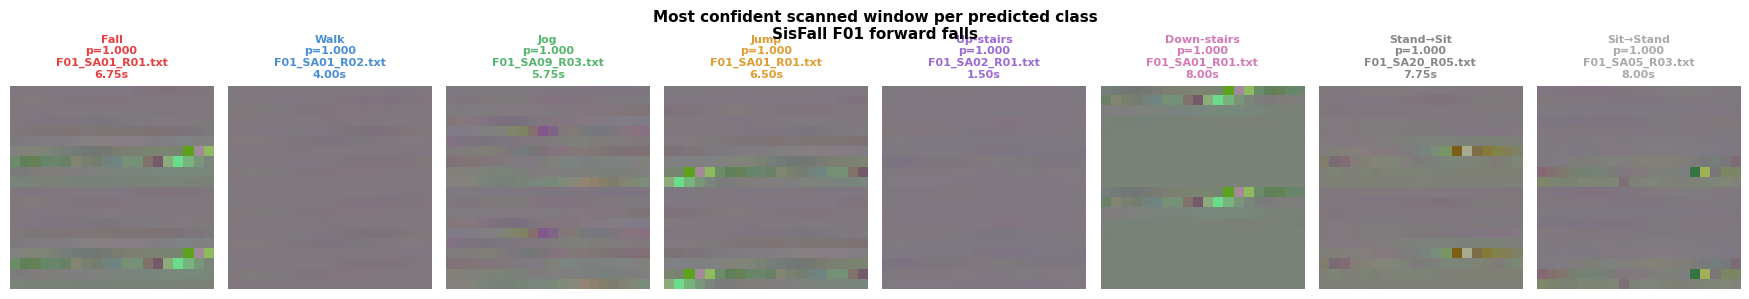

In [9]:
if len(fd_results) > 0:
    n_cl = len(FD_CLASS_LIST)
    fig, axes = plt.subplots(1, n_cl, figsize=(2.2 * n_cl, 3.2))
    if n_cl == 1:
        axes = [axes]

    for ax, label in zip(axes, FD_CLASS_LIST):
        cls_idx = FD_CLASS_LIST.index(label)
        best_idx = int(np.argmax(fd_probs[:, cls_idx]))
        best_prob = fd_probs[best_idx, cls_idx]
        row = fd_results.iloc[best_idx]
        img = to_image_repeat(fd_windows[best_idx])

        ax.imshow(img)
        name = FD_CLASS_NAMES[label]
        ax.set_title(f'{name}\np={best_prob:.3f}\n{row.recording}\n{row.center_s:.2f}s',
                     fontsize=8, color=FD_COLORS[label], fontweight='bold')
        ax.axis('off')

    fig.suptitle('Most confident scanned window per predicted class\nSisFall F01 forward falls',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 9. Overview Plots

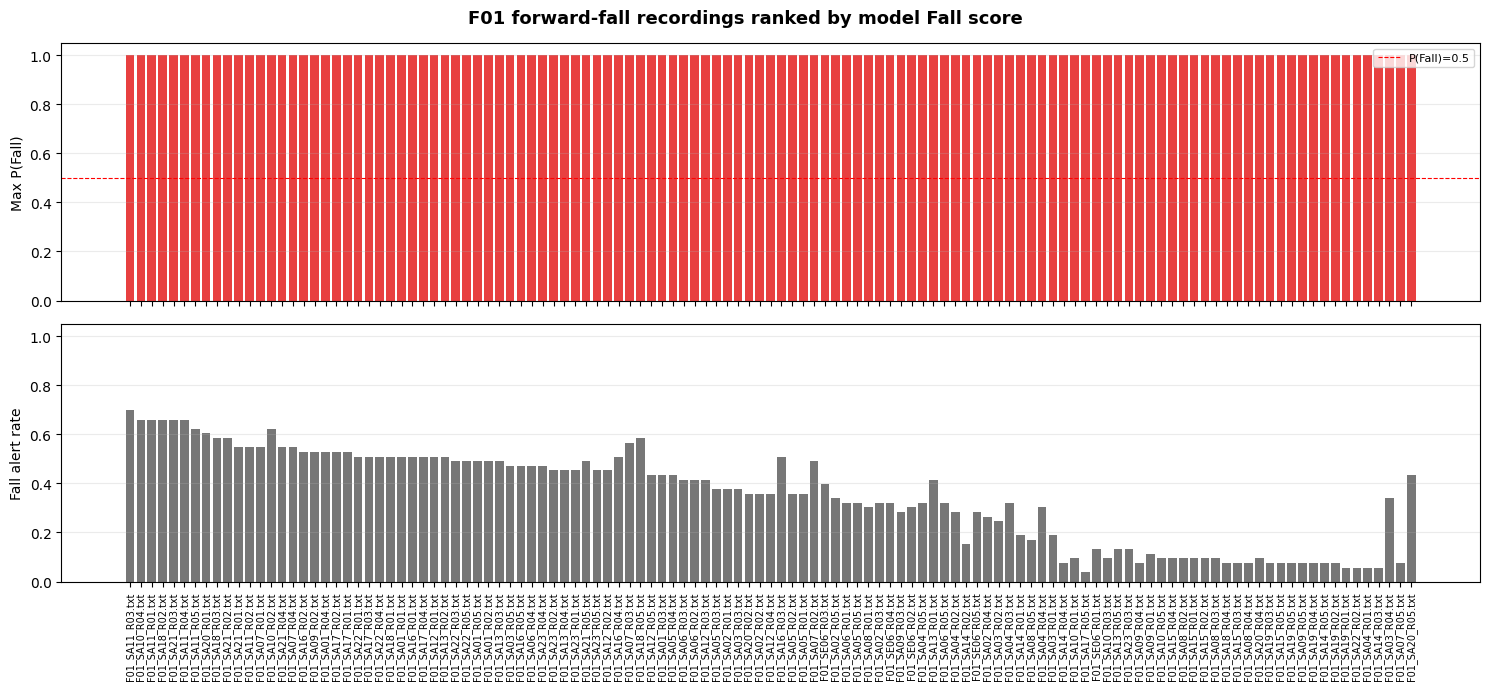

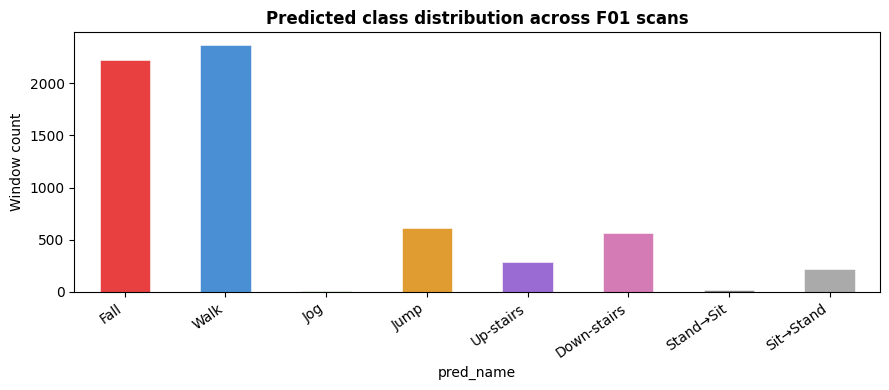

In [10]:
if len(fd_results) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

    ordered = recording_summary.sort_values('max_fall_prob', ascending=False).reset_index(drop=True)
    x = np.arange(len(ordered))
    colors = ['#e84040' if r >= 0.5 else '#4a8fd4' for r in ordered['max_fall_prob']]

    ax1.bar(x, ordered['max_fall_prob'], color=colors, edgecolor='none')
    ax1.axhline(0.5, color='red', ls='--', lw=0.8, label='P(Fall)=0.5')
    ax1.set_ylabel('Max P(Fall)')
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(True, axis='y', alpha=0.25)

    ax2.bar(x, ordered['fall_alert_rate'], color='#777777', edgecolor='none')
    ax2.set_ylabel('Fall alert rate')
    ax2.set_ylim(0, 1.05)
    ax2.set_xticks(x)
    ax2.set_xticklabels(ordered['recording'], rotation=90, fontsize=7)
    ax2.grid(True, axis='y', alpha=0.25)

    fig.suptitle('F01 forward-fall recordings ranked by model Fall score',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    fd_results['pred_name'].value_counts().reindex([FD_CLASS_NAMES[l] for l in FD_CLASS_LIST], fill_value=0).plot(
        kind='bar', ax=ax, color=[FD_COLORS[l] for l in FD_CLASS_LIST], edgecolor='white', linewidth=0.4)
    ax.set_ylabel('Window count')
    ax.set_title('Predicted class distribution across F01 scans', fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    plt.tight_layout()
    plt.show()


## 10. Time Scans — Prediction Shading, P(Fall), and Fall Logit

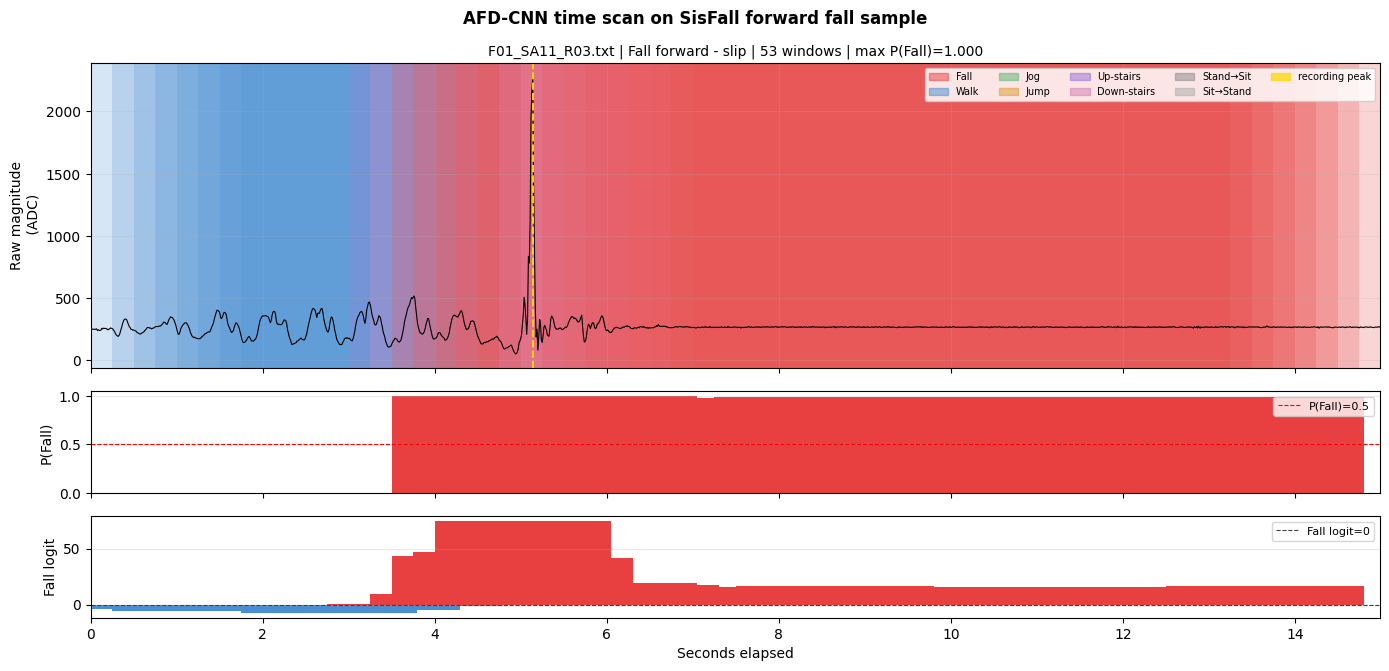

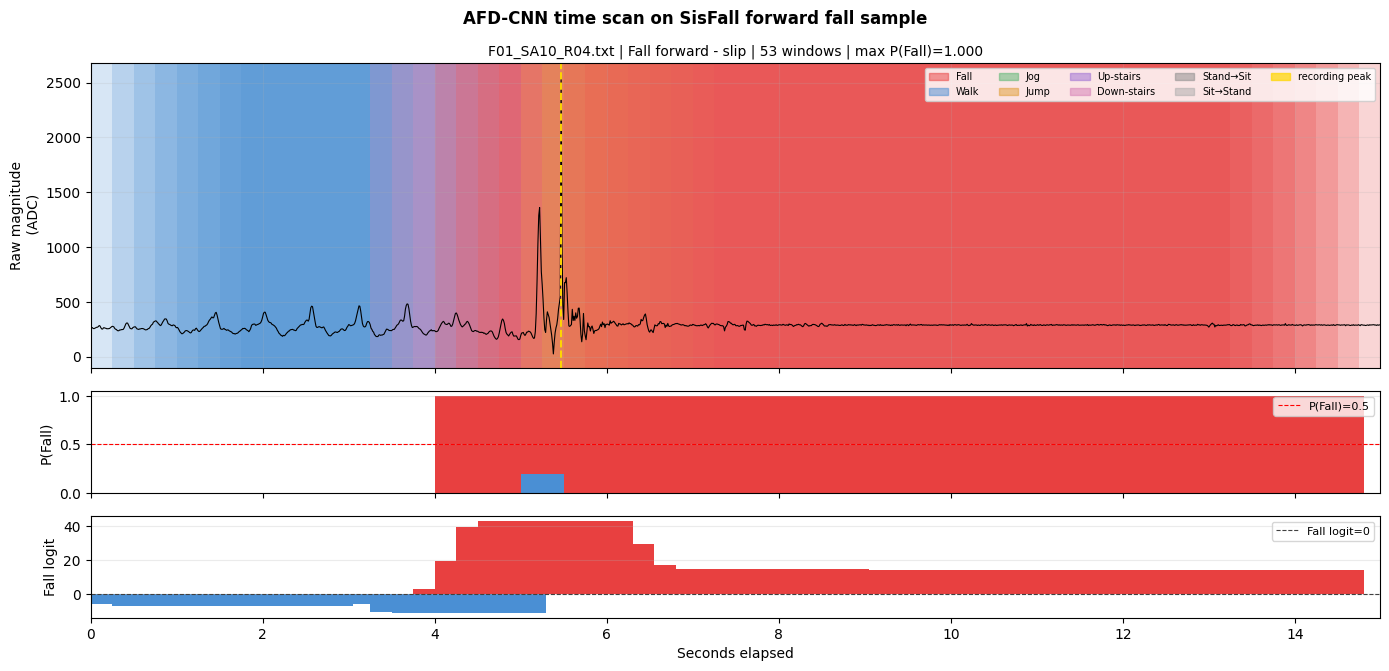

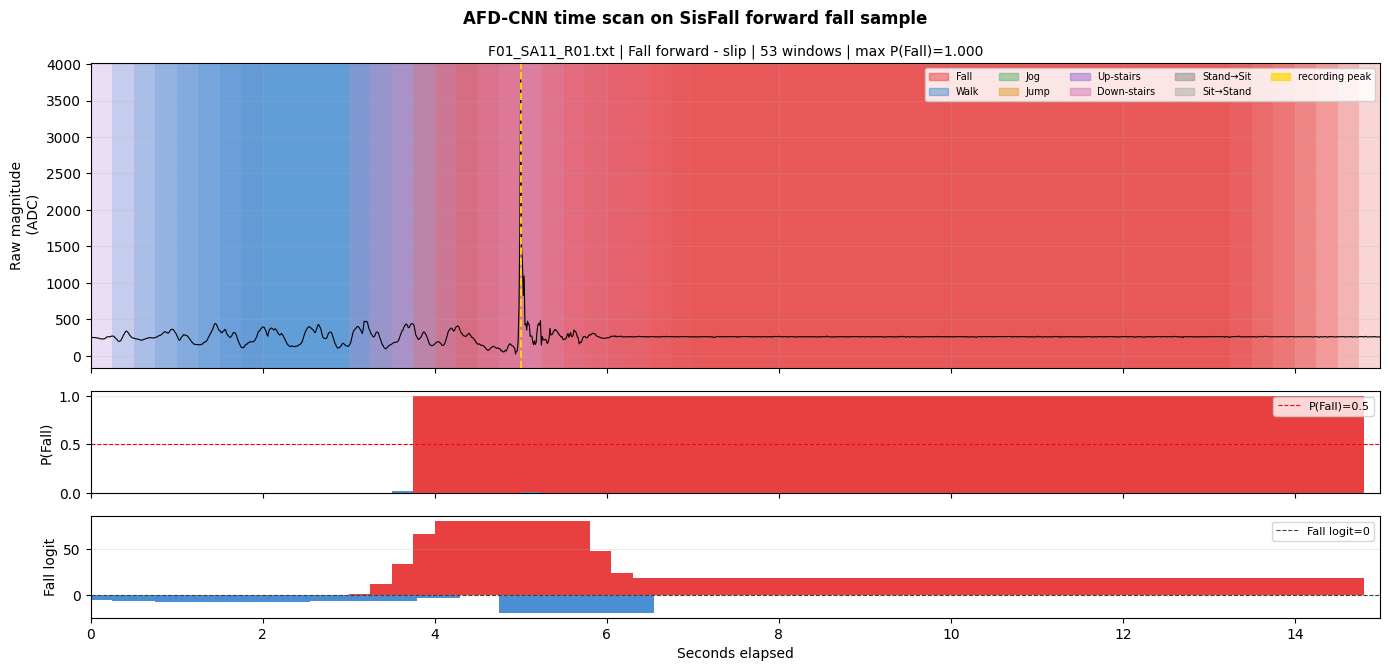

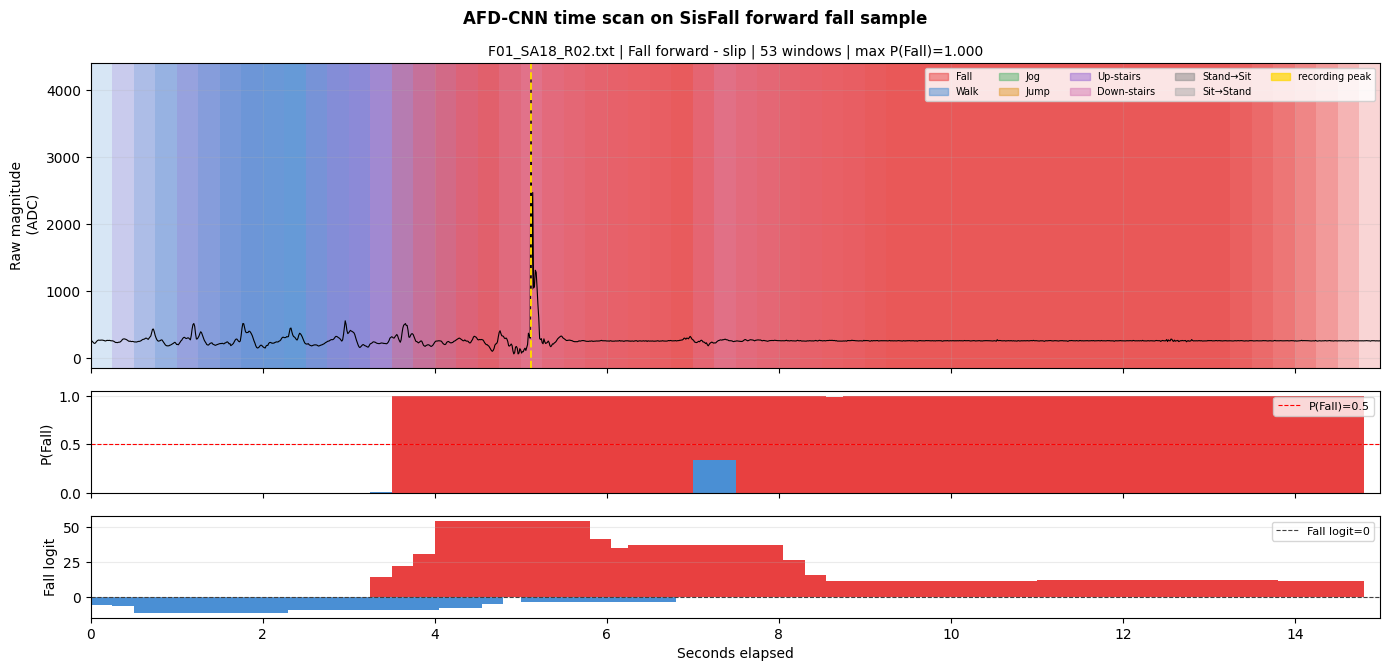

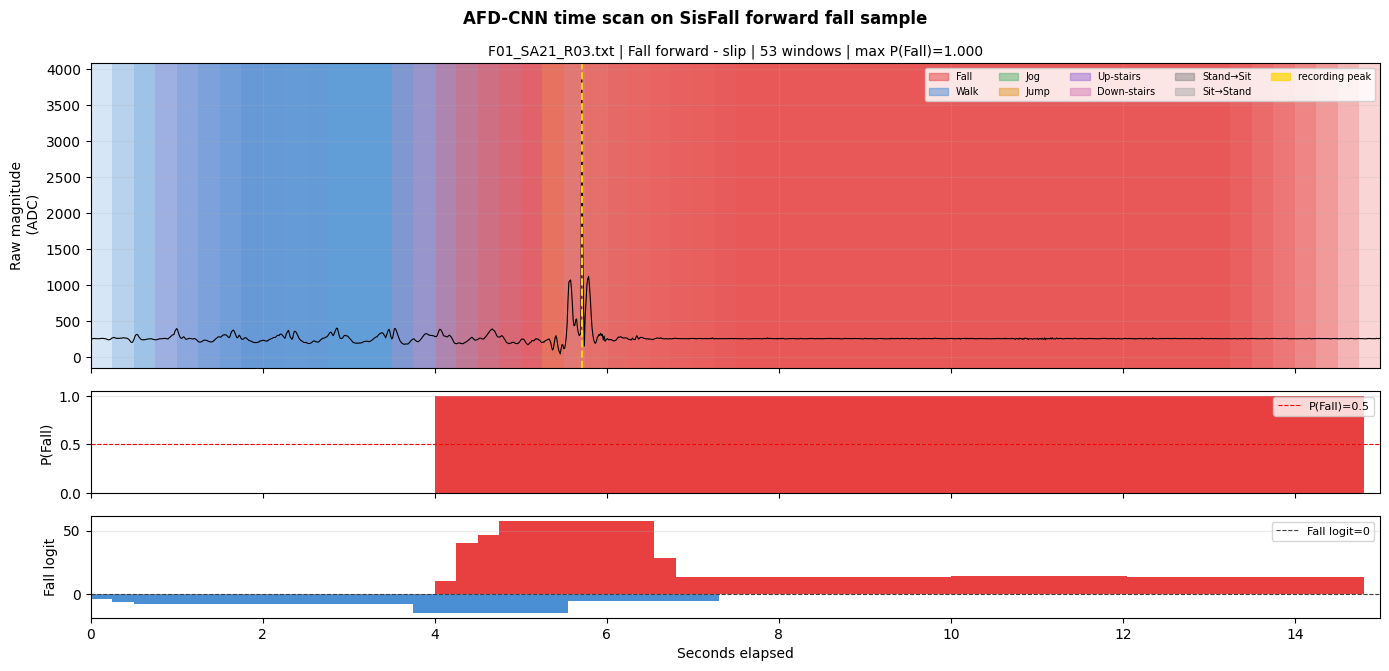

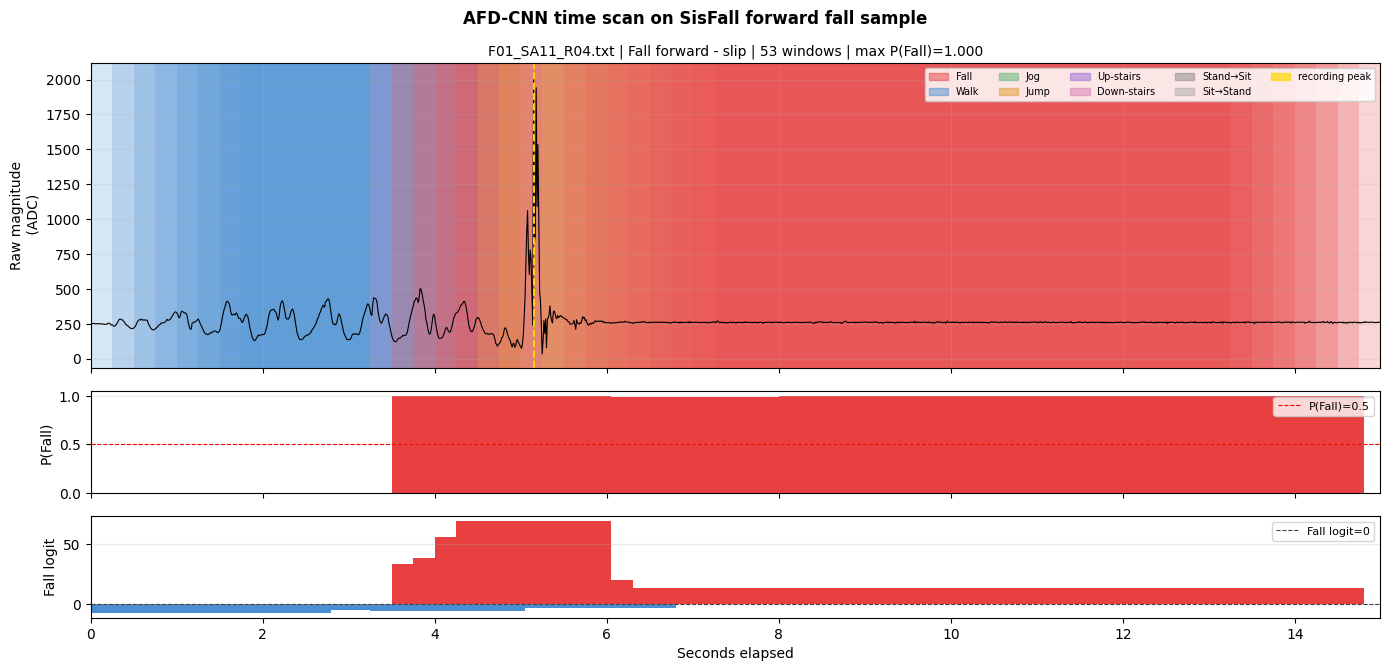

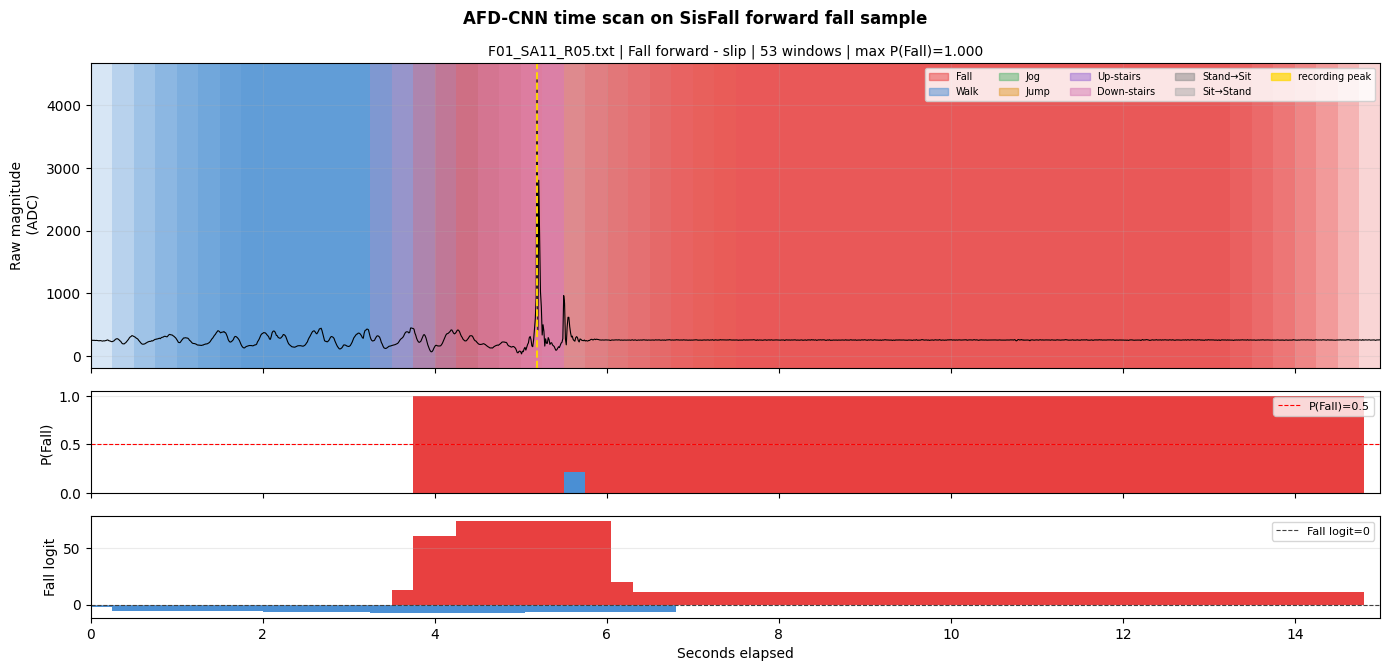

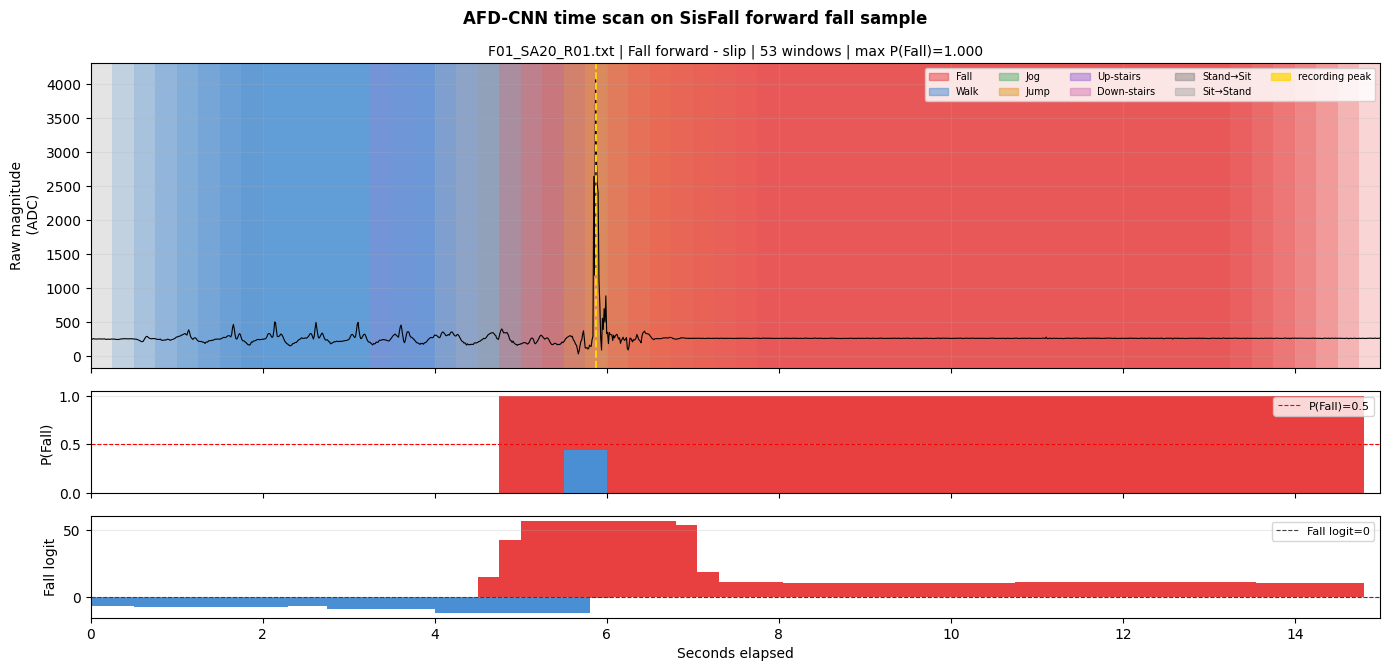

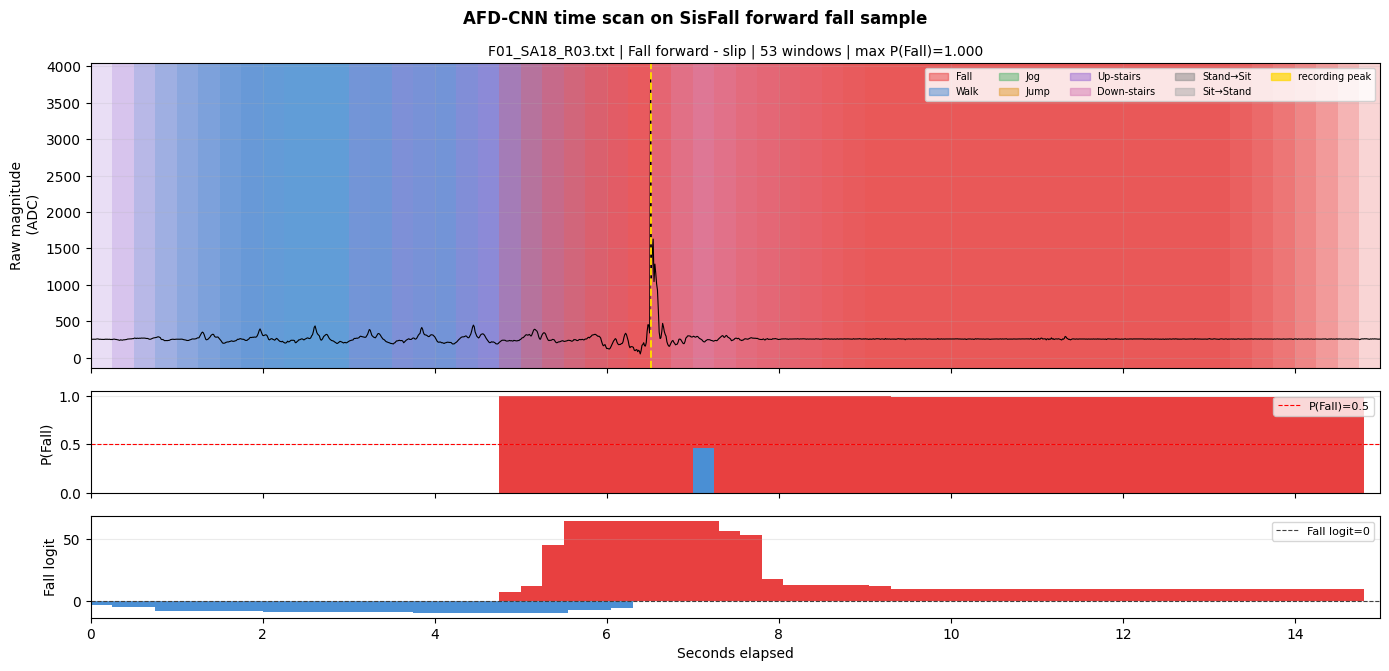

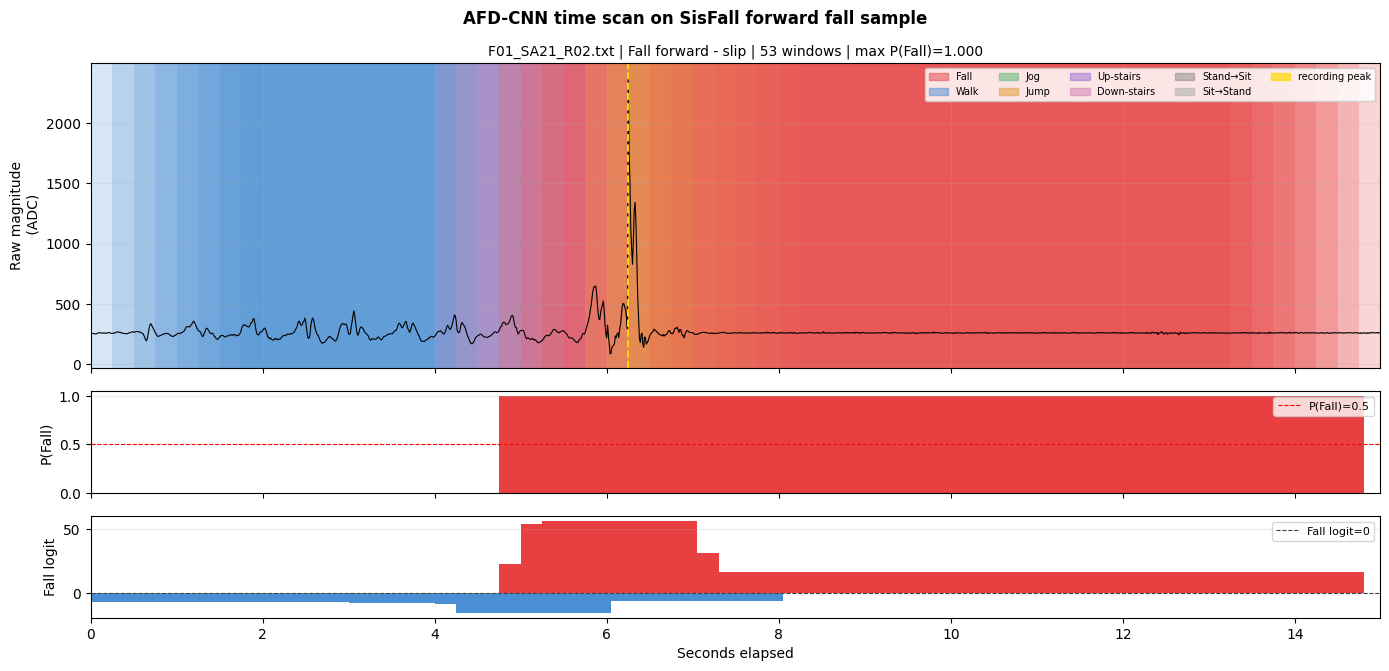

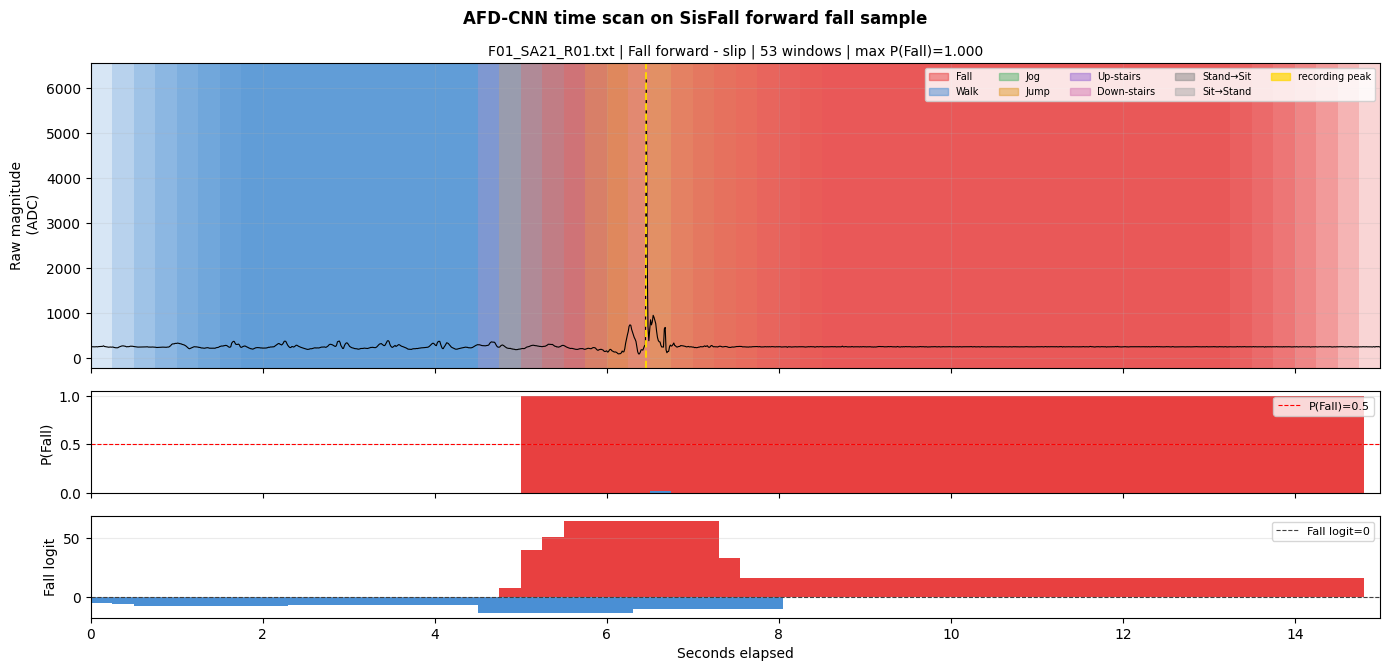

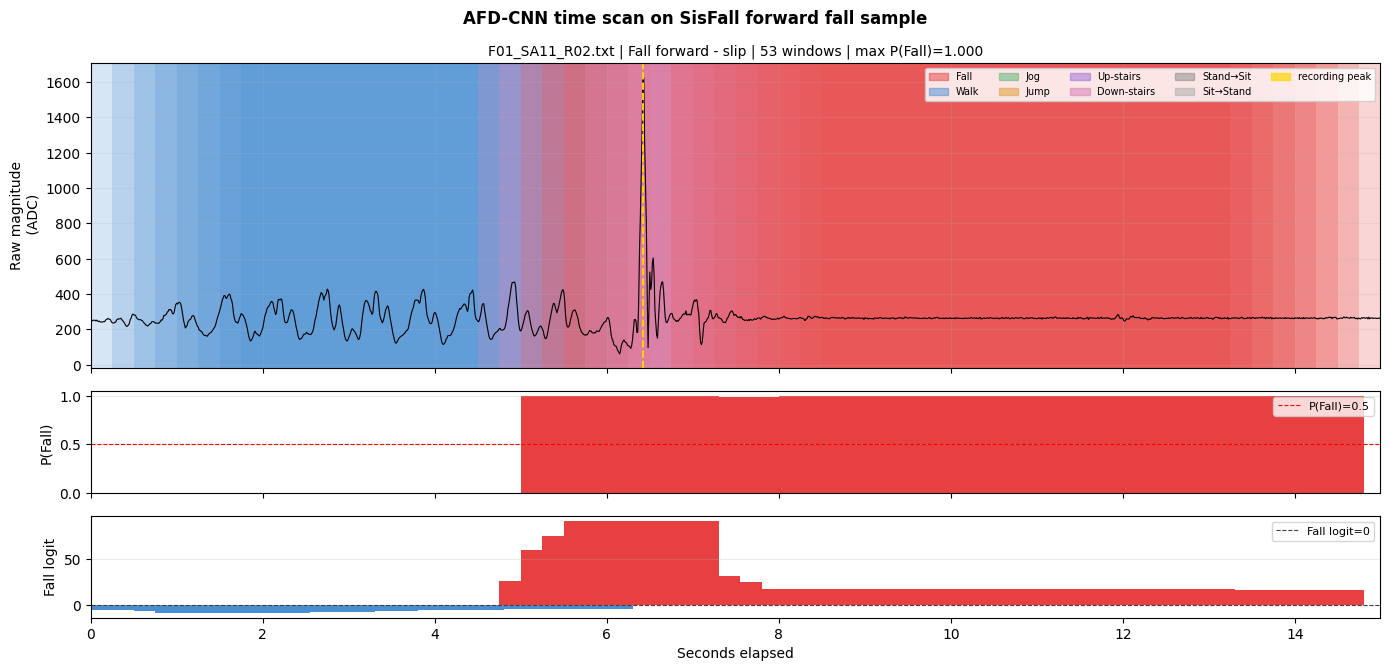

In [11]:
if len(fd_results) > 0:
    recordings_to_plot = recording_summary.head(MAX_RECORDINGS_TO_PLOT)['recording'].tolist()

    for recording in recordings_to_plot:
        rec = record_by_name[recording]
        rec_wins = fd_results[fd_results['recording'] == recording].copy()
        if rec_wins.empty:
            continue

        fig, (ax_sig, ax_fall, ax_logit) = plt.subplots(
            3, 1, figsize=(14, 6.8), sharex=True,
            gridspec_kw={'height_ratios': [3, 1, 1]},
        )

        ax_sig.plot(rec['t'], rec['mag_raw'], color='black', lw=0.8, label='‖ADXL345 acc‖')
        for _, row in rec_wins.iterrows():
            ax_sig.axvspan(row['start_s'], row['end_s'],
                           color=FD_COLORS.get(row['pred_label'], '#cccccc'),
                           alpha=0.22, linewidth=0)
        peak_idx = int(np.argmax(rec['mag_raw']))
        ax_sig.axvline(rec['t'][peak_idx], color='gold', lw=1.4, ls='--', label='recording peak')
        ax_sig.set_ylabel('Raw magnitude\n (ADC)')
        ax_sig.set_title(
            f"{recording} | {rec['description']} | {len(rec_wins)} windows | "
            f"max P(Fall)={rec_wins['fall_prob'].max():.3f}",
            fontsize=10,
        )
        ax_sig.legend(
            handles=[mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
                     for l in FD_CLASS_LIST] + [mpatches.Patch(color='gold', alpha=0.7, label='recording peak')],
            fontsize=7, loc='upper right', ncol=5, framealpha=0.85,
        )
        ax_sig.grid(True, alpha=0.2)

        colors_bar = ['#e84040' if p >= 0.5 else '#4a8fd4' for p in rec_wins['fall_prob']]
        ax_fall.bar(rec_wins['start_s'], rec_wins['fall_prob'],
                    width=FD_WIN_LEN / FD_FS_TRAIN * 0.9,
                    color=colors_bar, edgecolor='none', align='edge')
        ax_fall.axhline(0.5, color='red', ls='--', lw=0.8, label='P(Fall)=0.5')
        ax_fall.set_ylim(0, 1.05)
        ax_fall.set_ylabel('P(Fall)')
        ax_fall.legend(fontsize=8, loc='upper right')
        ax_fall.grid(True, axis='y', alpha=0.25)

        logit_vals = rec_wins['logit_fall'].to_numpy()
        colors_logit = ['#e84040' if z >= 0 else '#4a8fd4' for z in logit_vals]
        ax_logit.bar(rec_wins['start_s'], logit_vals,
                     width=FD_WIN_LEN / FD_FS_TRAIN * 0.9,
                     color=colors_logit, edgecolor='none', align='edge')
        ax_logit.axhline(0, color='0.25', ls='--', lw=0.8, label='Fall logit=0')
        ax_logit.set_ylabel('Fall logit')
        ax_logit.set_xlabel('Seconds elapsed')
        ax_logit.legend(fontsize=8, loc='upper right')
        ax_logit.grid(True, axis='y', alpha=0.25)

        x_min, x_max = float(rec['t'][0]), float(rec['t'][-1])
        ax_sig.set_xlim(x_min, x_max)
        ax_fall.set_xlim(x_min, x_max)
        ax_logit.set_xlim(x_min, x_max)

        fig.suptitle('AFD-CNN time scan on SisFall forward fall sample', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


## 10b. Time Scans — Signal and Fall Logit Only


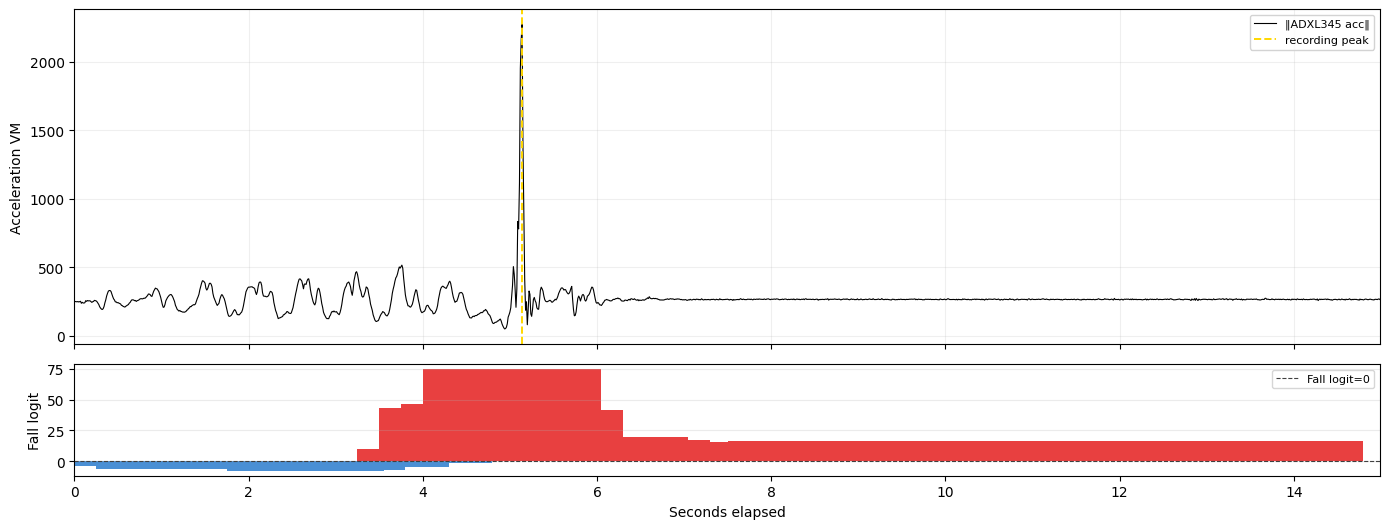

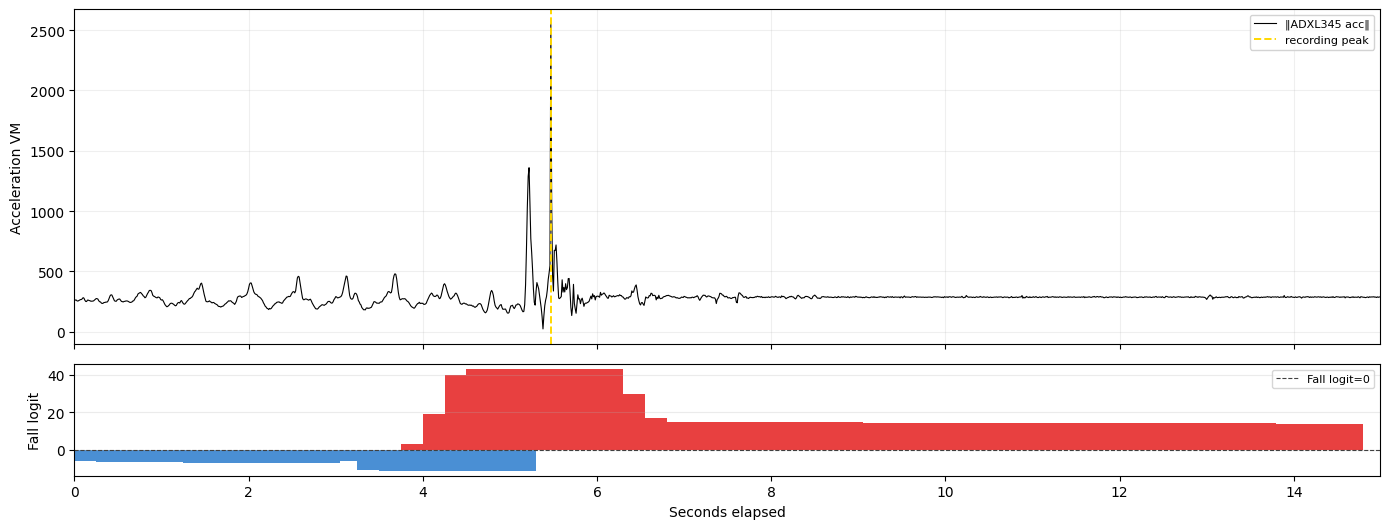

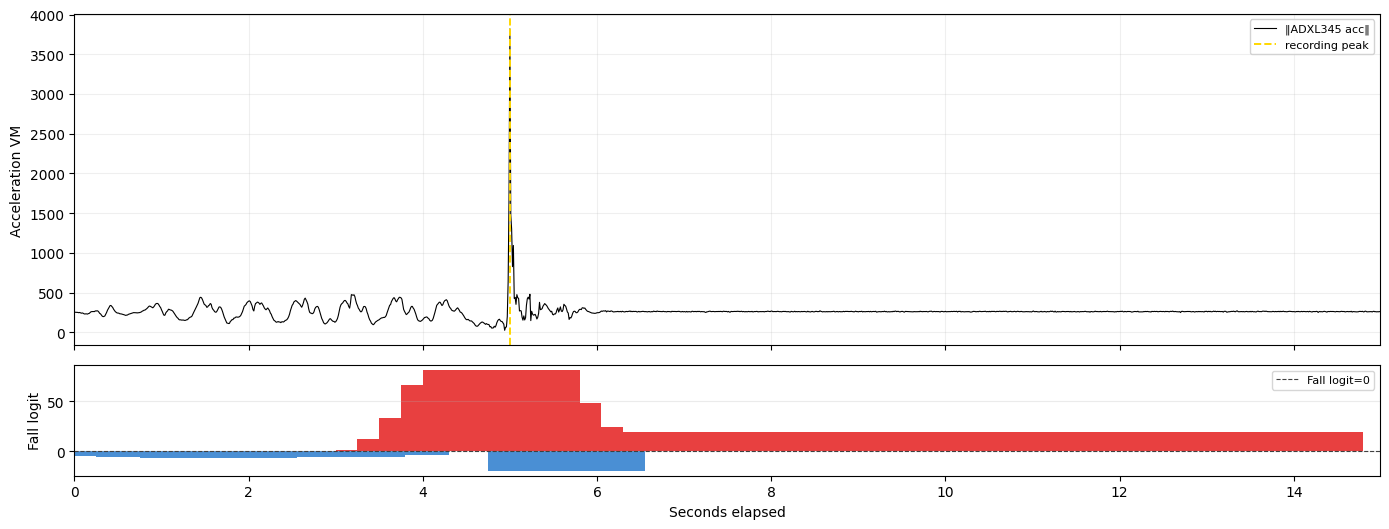

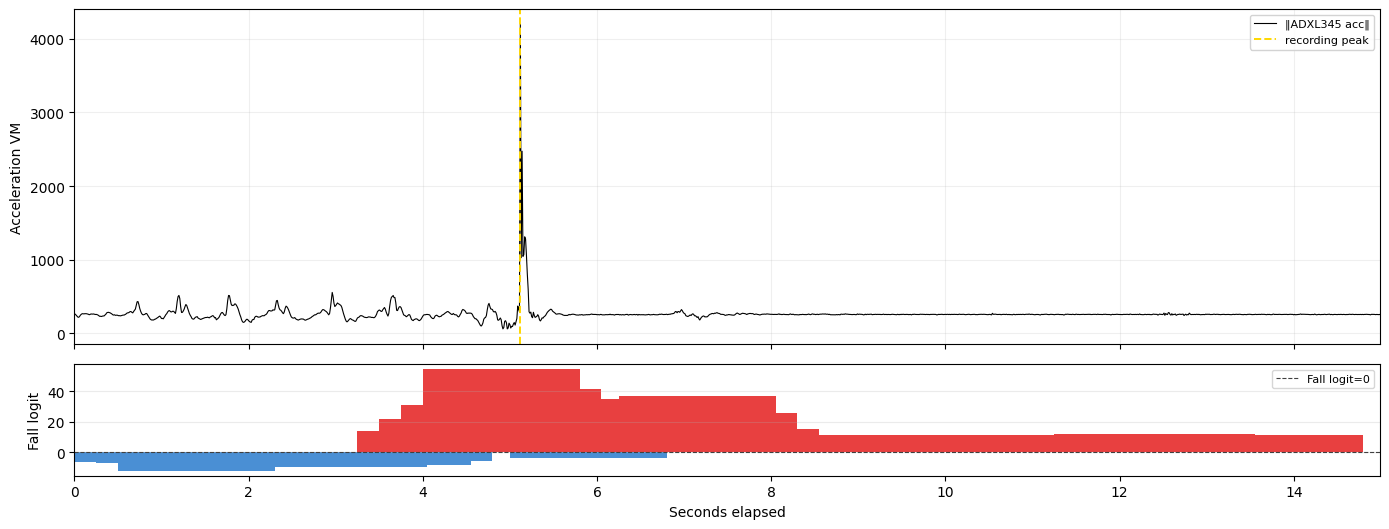

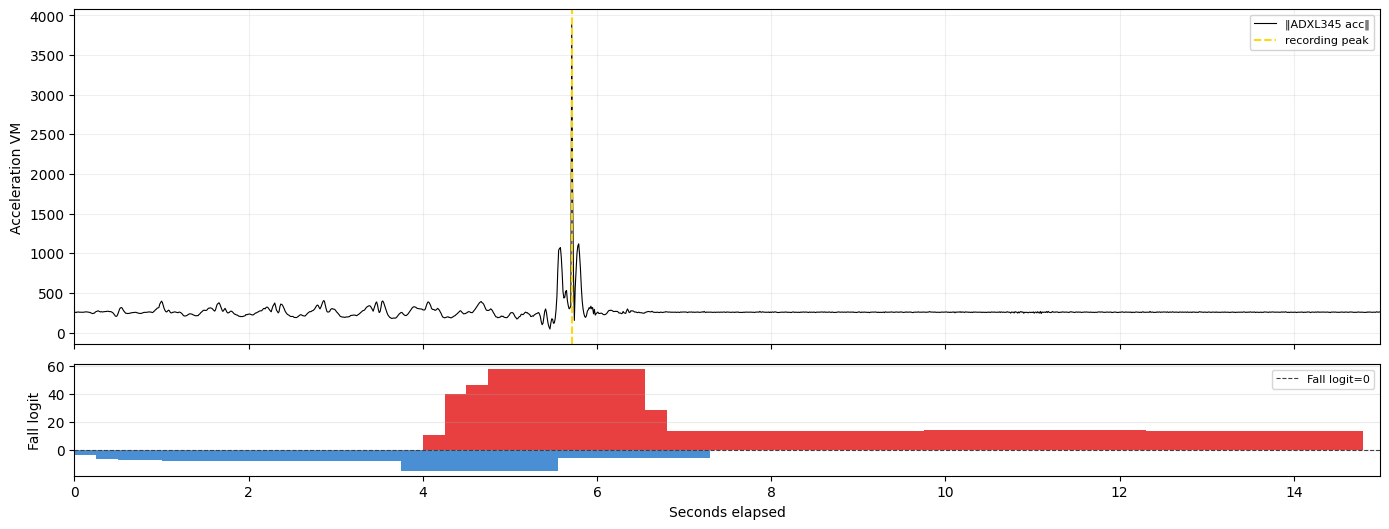

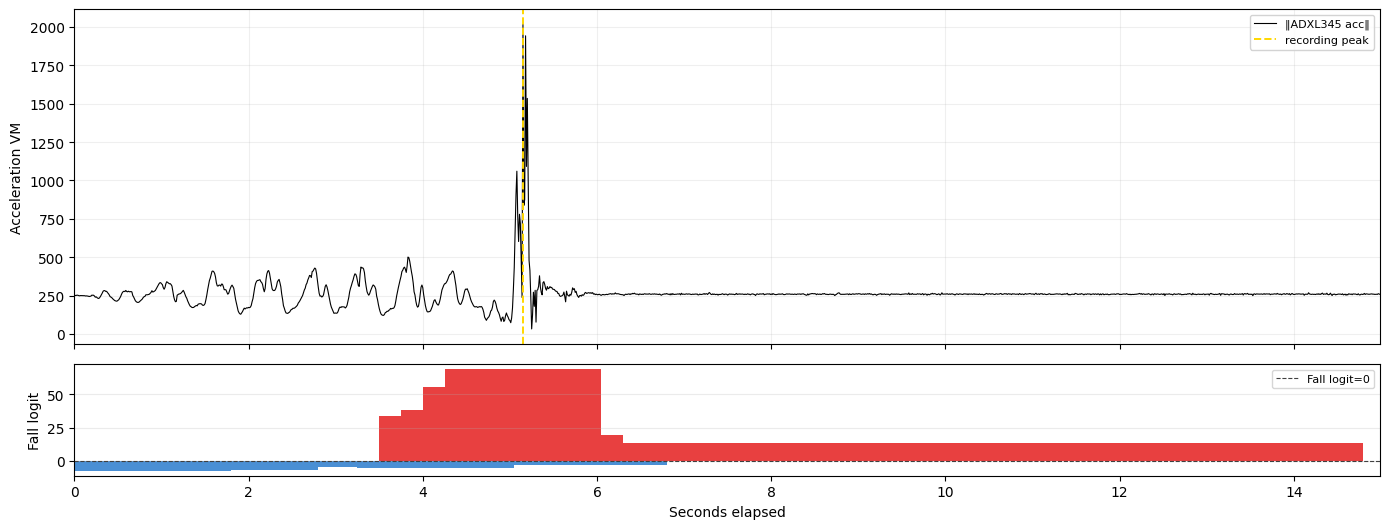

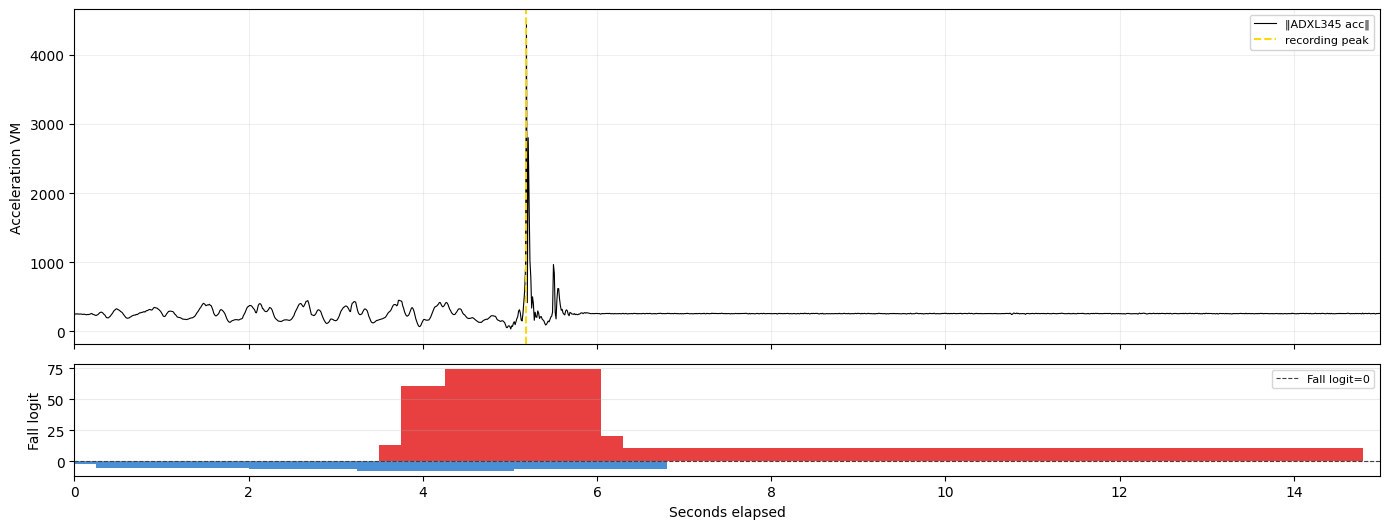

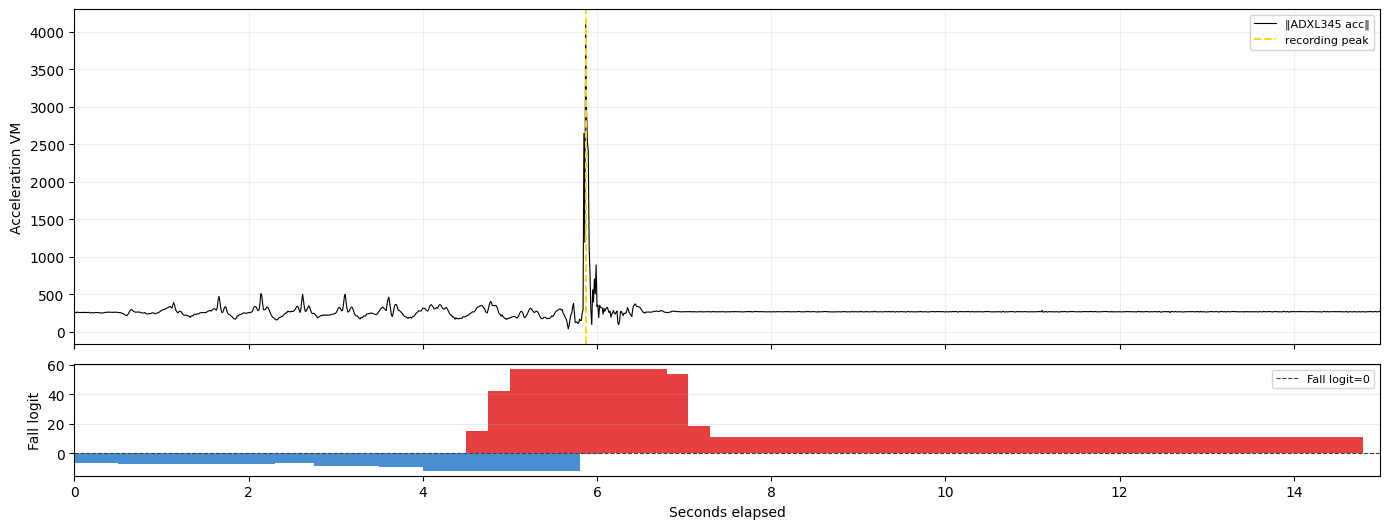

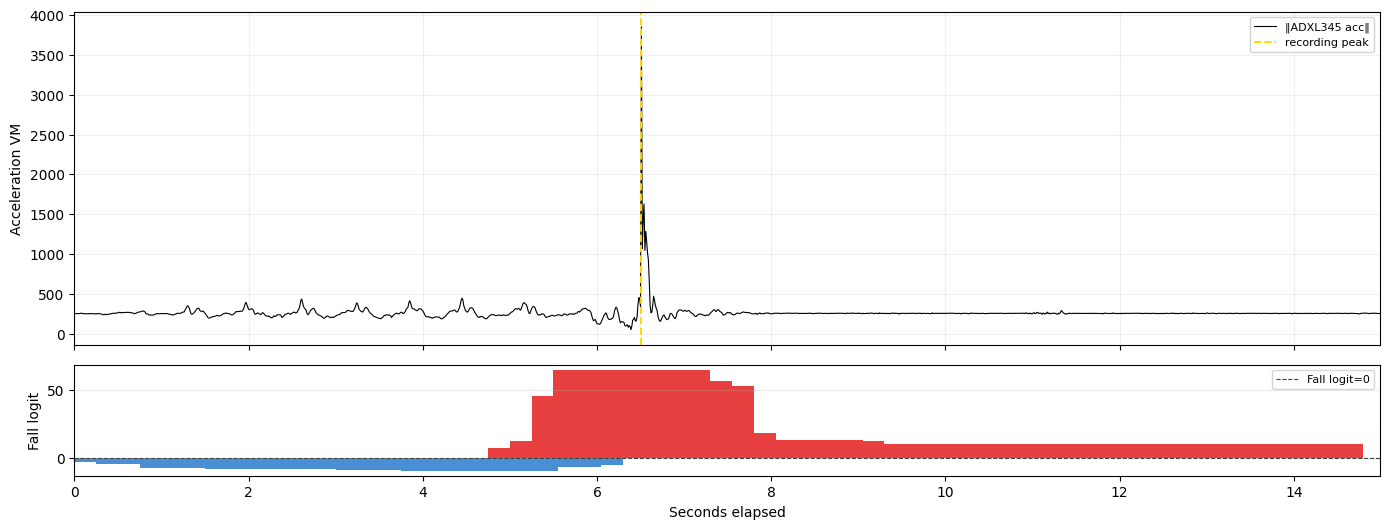

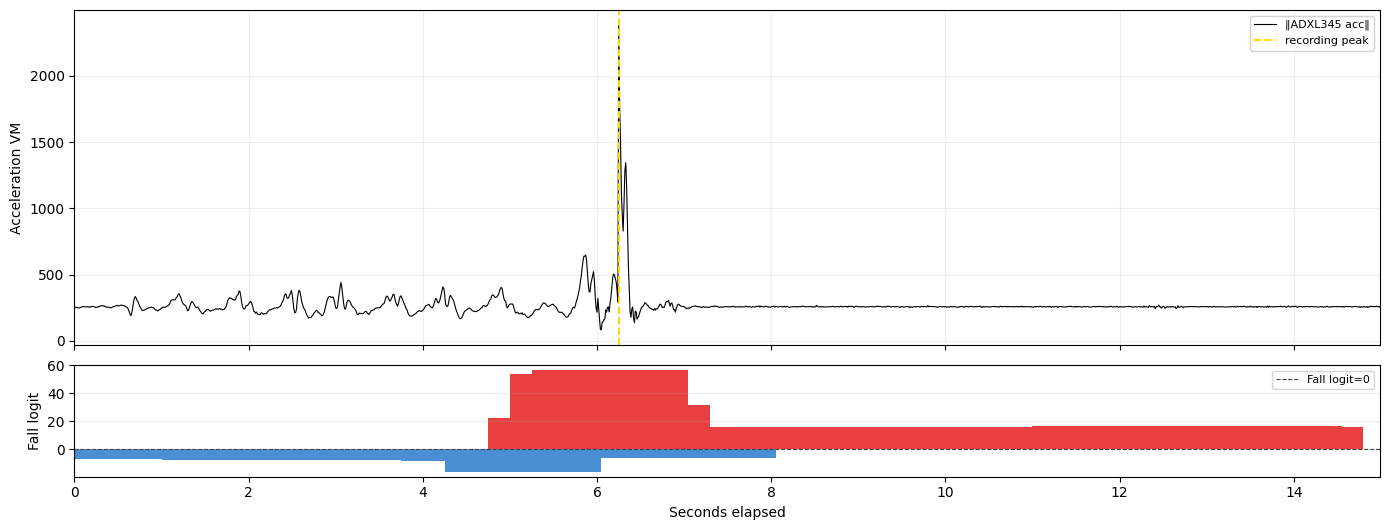

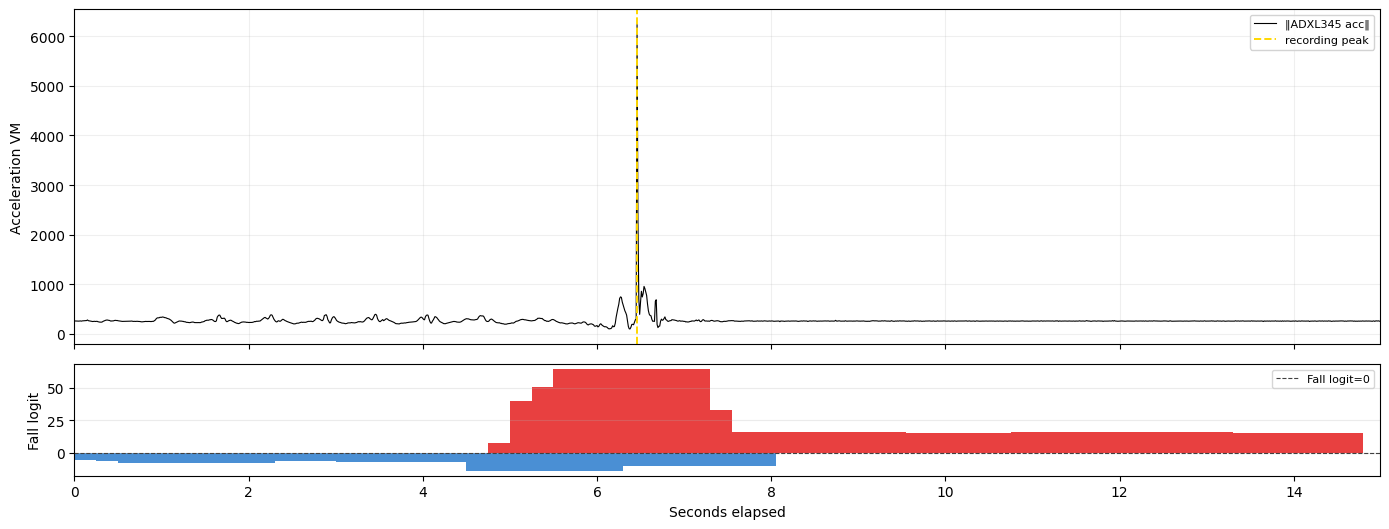

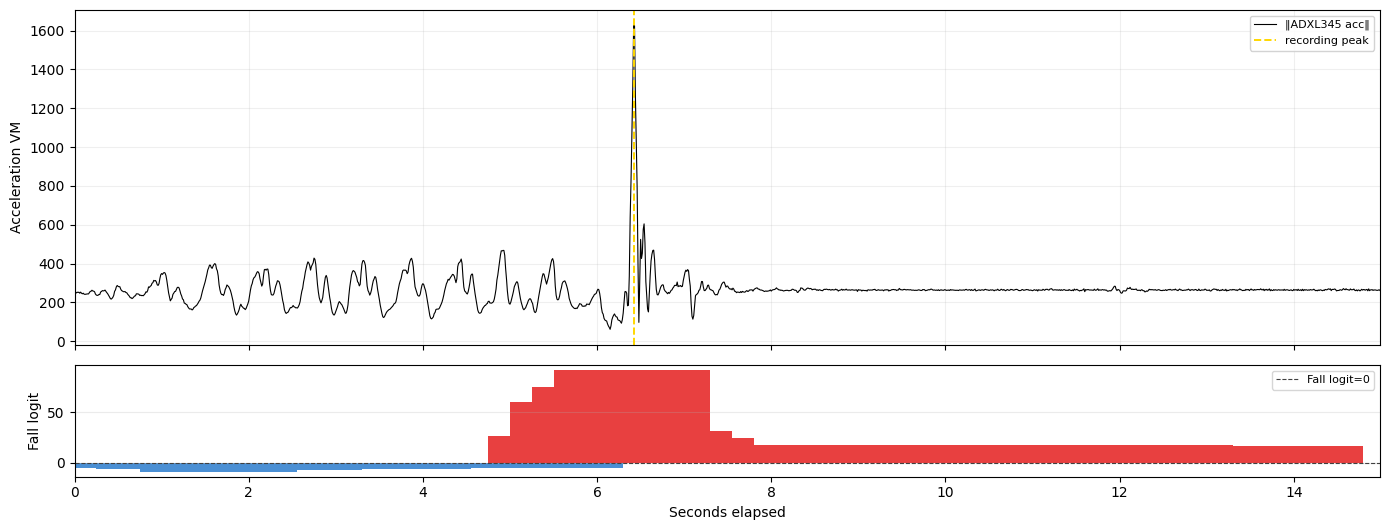

In [15]:
if len(fd_results) > 0:
    recordings_to_plot = recording_summary.head(MAX_RECORDINGS_TO_PLOT)['recording'].tolist()

    for recording in recordings_to_plot:
        rec = record_by_name[recording]
        rec_wins = fd_results[fd_results['recording'] == recording].copy()
        if rec_wins.empty:
            continue

        fig, (ax_sig, ax_logit) = plt.subplots(
            2, 1, figsize=(14, 5.4), sharex=True,
            gridspec_kw={'height_ratios': [3, 1]},
        )

        # Signal only: no prediction-shading background spans.
        ax_sig.plot(rec['t'], rec['mag_raw'], color='black', lw=0.8, label='‖ADXL345 acc‖')
        peak_idx = int(np.argmax(rec['mag_raw']))
        ax_sig.axvline(rec['t'][peak_idx], color='gold', lw=1.4, ls='--', label='recording peak')
        ax_sig.set_ylabel('Acceleration VM')
        ax_sig.legend(fontsize=8, loc='upper right', framealpha=0.85)
        ax_sig.grid(True, alpha=0.2)

        logit_vals = rec_wins['logit_fall'].to_numpy()
        colors_logit = ['#e84040' if z >= 0 else '#4a8fd4' for z in logit_vals]
        ax_logit.bar(rec_wins['start_s'], logit_vals,
                     width=FD_WIN_LEN / FD_FS_TRAIN * 0.9,
                     color=colors_logit, edgecolor='none', align='edge')
        ax_logit.axhline(0, color='0.25', ls='--', lw=0.8, label='Fall logit=0')
        ax_logit.set_ylabel('Fall logit')
        ax_logit.set_xlabel('Seconds elapsed')
        ax_logit.legend(fontsize=8, loc='upper right')
        ax_logit.grid(True, axis='y', alpha=0.25)

        x_min, x_max = float(rec['t'][0]), float(rec['t'][-1])
        ax_sig.set_xlim(x_min, x_max)
        ax_logit.set_xlim(x_min, x_max)

        plt.tight_layout()
        plt.show()


## 11. Fall Logit and P(Fall) Distributions

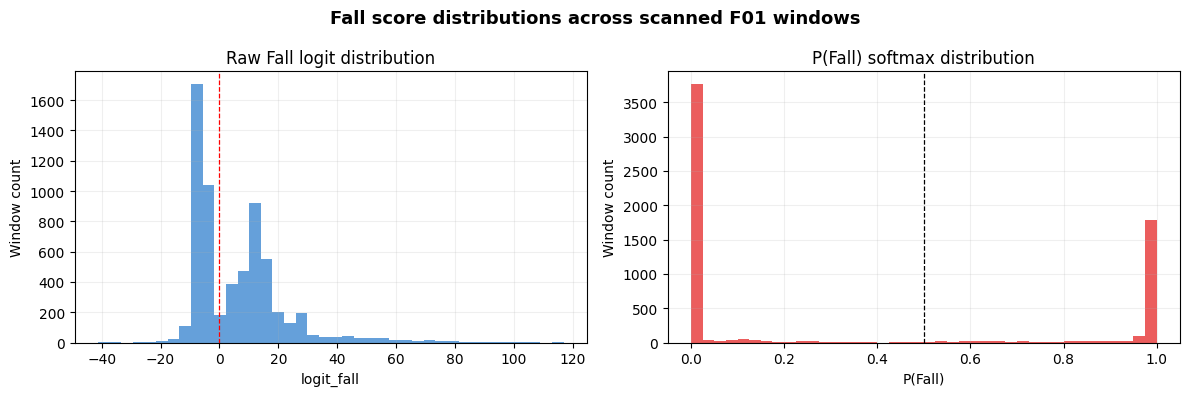

=== Fall score summary across all scanned F01 windows ===
          fall_prob   logit_fall     max_prob
count  6.306000e+03  6306.000000  6306.000000
mean   3.468543e-01     6.093681     0.954903
std    4.569070e-01    16.276186     0.105162
min    0.000000e+00   -41.316200     0.282780
25%    2.304104e-08    -6.136241     0.984922
50%    2.079954e-04     3.358762     0.999561
75%    9.944650e-01    13.386166     0.999994
max    9.999999e-01   116.913811     1.000000


In [13]:
if len(fd_results) > 0:
    fig, (ax_logit, ax_prob) = plt.subplots(1, 2, figsize=(12, 4))

    ax_logit.hist(fd_results['logit_fall'], bins=40, color='#4a8fd4', alpha=0.85)
    ax_logit.axvline(0, color='red', ls='--', lw=0.9)
    ax_logit.set_title('Raw Fall logit distribution')
    ax_logit.set_xlabel('logit_fall')
    ax_logit.set_ylabel('Window count')
    ax_logit.grid(True, alpha=0.2)

    ax_prob.hist(fd_results['fall_prob'], bins=np.linspace(0, 1, 41), color='#e84040', alpha=0.85)
    ax_prob.axvline(0.5, color='black', ls='--', lw=0.9)
    ax_prob.set_title('P(Fall) softmax distribution')
    ax_prob.set_xlabel('P(Fall)')
    ax_prob.set_ylabel('Window count')
    ax_prob.grid(True, alpha=0.2)

    fig.suptitle('Fall score distributions across scanned F01 windows', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('=== Fall score summary across all scanned F01 windows ===')
    print(fd_results[['fall_prob', 'logit_fall', 'max_prob']].describe().to_string())


## 12. Close TensorFlow Session

In [14]:
fd_sess.close()
print('TF session closed.')


TF session closed.
